#### `Import Libraries`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### `Questions`
> What is the total revenue generated by each product category?

> Which product has the highest and lowest sales quantity?

> What is the average revenue per transaction?

> Which city is generating the most revenue?

> Are there any days where no sales happened? (data observation)

In [2]:
# Sales data for Ramesh's retail store — last 10 transactions
data = {
    'Date': ['2024-01-01', '2024-01-02', '2024-01-02', '2024-01-03',
             '2024-01-04', '2024-01-05', '2024-01-05', '2024-01-06',
             '2024-01-07', '2024-01-08'],

    'Product': ['Notebook', 'Pen', 'Stapler', 'Notebook',
                'Eraser', 'Pen', 'Notebook', 'Stapler',
                'Eraser', 'Pen'],

    'Category': ['Stationery', 'Stationery', 'Office Supply', 'Stationery',
                 'Stationery', 'Stationery', 'Stationery', 'Office Supply',
                 'Stationery', 'Stationery'],

    'City': ['Pune', 'Mumbai', 'Pune', 'Delhi',
             'Mumbai', 'Pune', 'Delhi', 'Mumbai',
             'Pune', 'Delhi'],

    'Quantity_Sold': [5, 10, 2, 8, 15, 12, 6, 3, 20, 9],

    'Unit_Price': [40, 5, 120, 40, 3, 5, 40, 120, 3, 5]
}

#### `Step 1 :- Load and Explore Data`

In [13]:
# Create DataFrame and convert Date column to datetime
data_frame = pd.DataFrame(data)

data_frame['Date'] = pd.to_datetime(data_frame['Date'])

data_frame

,Date,Product,Category,City,Quantity_Sold,Unit_Price
0,2024-01-01,Notebook,Stationery,Pune,5,40
1,2024-01-02,Pen,Stationery,Mumbai,10,5
2,2024-01-02,Stapler,Office Supply,Pune,2,120
3,2024-01-03,Notebook,Stationery,Delhi,8,40
4,2024-01-04,Eraser,Stationery,Mumbai,15,3
5,2024-01-05,Pen,Stationery,Pune,12,5
6,2024-01-05,Notebook,Stationery,Delhi,6,40
7,2024-01-06,Stapler,Office Supply,Mumbai,3,120
8,2024-01-07,Eraser,Stationery,Pune,20,3
9,2024-01-08,Pen,Stationery,Delhi,9,5


#### `Step 2 :- Add Revenue Column`

In [4]:
# Calculate revenue for each transaction
data_frame['Revenue'] = data_frame['Quantity_Sold'] * data_frame['Unit_Price']

data_frame

,Date,Product,Category,City,Quantity_Sold,Unit_Price,Revenue
0,2024-01-01,Notebook,Stationery,Pune,5,40,200
1,2024-01-02,Pen,Stationery,Mumbai,10,5,50
2,2024-01-02,Stapler,Office Supply,Pune,2,120,240
3,2024-01-03,Notebook,Stationery,Delhi,8,40,320
4,2024-01-04,Eraser,Stationery,Mumbai,15,3,45
5,2024-01-05,Pen,Stationery,Pune,12,5,60
6,2024-01-05,Notebook,Stationery,Delhi,6,40,240
7,2024-01-06,Stapler,Office Supply,Mumbai,3,120,360
8,2024-01-07,Eraser,Stationery,Pune,20,3,60
9,2024-01-08,Pen,Stationery,Delhi,9,5,45


#### `Step 3 :- Total Revenue by Category`

In [5]:
# Group by category and sum revenue
category_revenue = data_frame.groupby('Category')['Revenue'].sum()

category_revenue

Category
Office Supply     600
Stationery       1020
Name: Revenue, dtype: int64

#### `Step 4 :- Product with Highest & Lowest Quantity Sold`

In [6]:
# Find product with max quantity sold
highest_product = data_frame.loc[data_frame['Quantity_Sold'].idxmax(), ['Product', 'Quantity_Sold']]

highest_product

Product          Eraser
Quantity_Sold        20
Name: 8, dtype: object

In [7]:
# Find product with min quantity sold
lowest_product = data_frame.loc[data_frame['Quantity_Sold'].idxmin(), ['Product', 'Quantity_Sold']]

lowest_product

Product          Stapler
Quantity_Sold          2
Name: 2, dtype: object

#### `Step 5 :- Average Revenue per Transaction`

In [8]:
# Calculate mean revenue per transaction
average_revenue = data_frame['Revenue'].mean()

average_revenue

np.float64(162.0)

#### `Step 6 :- Total Revenue by City`

In [9]:
# Group by city and sum revenue
city_revenue = data_frame.groupby('City')['Revenue'].sum()

city_revenue

City
Delhi     605
Mumbai    455
Pune      560
Name: Revenue, dtype: int64

#### `Step 7 :- Days with No Sales`

In [10]:
# Identify missing dates in the sales sequence
all_days = pd.date_range(data_frame['Date'].min(), data_frame['Date'].max())

missing_days = all_days.difference(data_frame['Date'])

missing_days

DatetimeIndex([], dtype='datetime64[us]', freq='D')

#### `Step 8 :- Chart — Revenue by City`

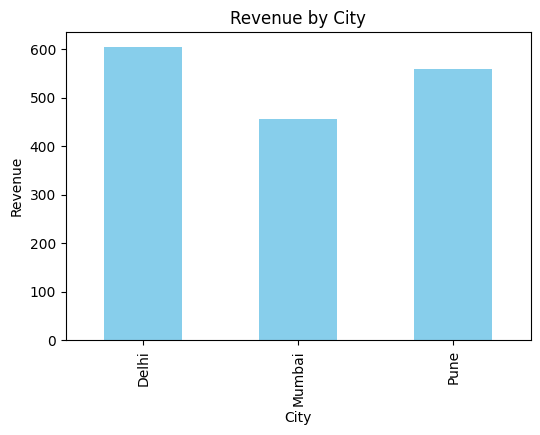

In [11]:
# Bar chart showing revenue per city
plt.figure(figsize = (6, 4))

city_revenue.plot(kind = 'bar', color = 'skyblue')

plt.title('Revenue by City')

plt.ylabel('Revenue')

plt.show()

#### `Step 9 :- Print Outputs`

In [12]:
print(f'Category Revenue:\n {category_revenue}')

print(f'\nHighest Quantity Sold:\n {highest_product}')

print(f'\nLowest Quantity Sold:\n {lowest_product}')

print(f'\nAverage Revenue per Transaction: {average_revenue}')

print(f'\nCity Revenue:\n {city_revenue}')

Category Revenue:
 Category
Office Supply     600
Stationery       1020
Name: Revenue, dtype: int64

Highest Quantity Sold:
 Product          Eraser
Quantity_Sold        20
Name: 8, dtype: object

Lowest Quantity Sold:
 Product          Stapler
Quantity_Sold          2
Name: 2, dtype: object

Average Revenue per Transaction: 162.0

City Revenue:
 City
Delhi     605
Mumbai    455
Pune      560
Name: Revenue, dtype: int64


#### `Information`
> Rows: 10

> Columns: 7 (Date, Product, Category, City, Quantity_Sold, Unit_Price, Revenue)

> Data Types: DateTime, Object, Integer

#### `Data Insights`
> Stationery category generated the most revenue (₹1020).

> Eraser sold the highest quantity (20 units).

> Stapler sold the lowest quantity (2 units).

> Average revenue per transaction is ₹162.

> Delhi city generated the highest revenue (₹605).

> Sales happened every day — no missing days.

#### `Business Insights`
> Stationery items are the backbone of Ramesh’s shop.

> Delhi customers are contributing the most revenue, followed by Pune.

> Stapler is underperforming — possibly due to high price (₹120) compared to demand.

> Erasers are selling in bulk, showing strong demand at low price (₹3).

#### `Risks`
> Over‑reliance on stationery category.

> Weak sales in Mumbai.

> Stapler may waste shelf space due to low demand.

#### `Opportunities`
> Stock more Erasers and Notebooks — high‑velocity items.

> Promotions in Mumbai to boost sales.

> Consider lowering Stapler price or replacing with alternative.

#### `Recommendations`
> Keep at least 15–20 units of Erasers and Notebooks in stock before weekends.

> Reduce Stapler inventory or bundle it with other products.

> Launch discount offers in Mumbai to attract customers.

> Track daily sales patterns to identify peak demand days.

#### `Expected Business Impact`
> Higher revenue from stocking popular items.

> Better customer satisfaction by avoiding stockouts.

> Improved sales in weaker cities through targeted promotions.

#### `Future Prediction`
> Stationery will remain the top category next month.

> Delhi will likely continue leading in revenue.

> Stapler sales may decline further unless pricing or bundling strategy is applied.